# **Problem Statement**

## Business Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62 bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert

## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.

* **ID**: ID of the lead.
* **age**: Age of the lead.
* **current_occupation**: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'.
* **first_interaction**: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'.
* **profile_completed**: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%).
* **website_visits**: How many times has a lead visited the website.
* **time_spent_on_website**: Total time spent on the website in seconds.
* **page_views_per_visit**: Average number of pages on the website viewed during the visits.
* **last_activity**: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc.
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc.
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc.

* **print_media_type1**: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* **print_media_type2**: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* **digital_media**: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* **educational_channels**: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* **referral**: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* **status**: Flag indicating whether the lead was converted to a paid customer or not.

# **Installing and Importing the Necessary libraries**

In [1]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2

  Using cached numpy-2.0.2.tar.gz (18.9 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      + C:\Users\berni\anaconda3\envs\ml-lab\python.exe C:\Users\berni\AppData\Local\Temp\pip-install-v5zcenmy\numpy_232fed31cda546ab806d11f4aa7488ae\vendored-meson\meson\meson.py setup C:\Users\berni\AppData\Local\Temp\pip-install-v5zcenmy\numpy_232fed31cda546ab806d11f4aa7488ae C:\Users\berni\AppData\Local\Temp\pip-install-v5zcenmy\numpy_232fed31cda546ab806d11f4aa7488ae\.mesonpy-qbc7nbck -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\berni\AppData\Local\Temp\pip-install-v5zcenmy\numpy_232fed31cda546ab806d11f4aa7488ae\.mesonpy-qbc7nbck\meson-python-native-file.ini
      The Meson build system
      Version: 1.4.99
      Source dir: C:\Users\berni\AppData\Local\Temp\pip-install-v5zcenmy\numpy_232fed31cda546ab806d11f4aa7488ae
      Build dir: C:\Users\berni\AppData\Local\Temp\pip-install-v5zcenmy\numpy_232fed

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import sys
import os

sys.path.append(os.path.abspath('..'))

In [3]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries for different classifiers
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# **Loading the dataset**

In [4]:
# Read the CSV file
from src.data_loader import load_data
original_dataset = load_data('../data/ExtraaLearn.csv')


In [5]:
#copy of the data for the machine learning model
data = original_dataset.copy()

## Overview of the dataset

In [6]:
from IPython.display import display

def head_and_tail(df, n=5):
    print("Head:")
    display(df.head(n))
    print("\nTail:")
    display(df.tail(n))

head_and_tail(data)


Head:


,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0



Tail:


,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
4607,EXT4608,35,Unemployed,Mobile App,Medium,15,360,2.170,Phone Activity,No,No,No,Yes,No,0
4608,EXT4609,55,Professional,Mobile App,Medium,8,2327,5.393,Email Activity,No,No,No,No,No,0
4609,EXT4610,58,Professional,Website,High,2,212,2.692,Email Activity,No,No,No,No,No,1
4610,EXT4611,57,Professional,Mobile App,Medium,1,154,3.879,Website Activity,Yes,No,No,No,No,0
4611,EXT4612,55,Professional,Website,Medium,4,2290,2.075,Phone Activity,No,No,No,No,No,0


In [7]:
data.shape

(4612, 15)

* The dataset has 4612 rows and 15 columns

In [8]:
print("\nDataset information:")
data.info()


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   str    
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   str    
 3   first_interaction      4612 non-null   str    
 4   profile_completed      4612 non-null   str    
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   str    
 9   print_media_type1      4612 non-null   str    
 10  print_media_type2      4612 non-null   str    
 11  digital_media          4612 non-null   str    
 12  educational_channels   4612 non-null   str    
 13  referral               4612 non-null   str    
 14  status                 4612 non-null   int64 

In [9]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

In [10]:
# checking the number of unique values
data["ID"].nunique()

4612

In [11]:
print("Actual column names:", data.columns.tolist())

Actual column names: ['ID', 'age', 'current_occupation', 'first_interaction', 'profile_completed', 'website_visits', 'time_spent_on_website', 'page_views_per_visit', 'last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral', 'status']


In [12]:
from src.data_preprocessing import preprocess_data
pdata = preprocess_data(data)
pdata

,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4607,35,Unemployed,Mobile App,Medium,15,360,2.170,Phone Activity,No,No,No,Yes,No,0
4608,55,Professional,Mobile App,Medium,8,2327,5.393,Email Activity,No,No,No,No,No,0
4609,58,Professional,Website,High,2,212,2.692,Email Activity,No,No,No,No,No,1
4610,57,Professional,Mobile App,Medium,1,154,3.879,Website Activity,Yes,No,No,No,No,0


In [13]:
pdata.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000


In [14]:
pdata.isnull().sum()

age                      0
current_occupation       0
first_interaction        0
profile_completed        0
website_visits           0
time_spent_on_website    0
page_views_per_visit     0
last_activity            0
print_media_type1        0
print_media_type2        0
digital_media            0
educational_channels     0
referral                 0
status                   0
dtype: int64

* There are no null values in the dataset.

# **Exploratory Data Analysis**

**The below functions need to be defined to carry out the EDA.**

In [15]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [16]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None, horizontal=True):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)+
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [17]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [18]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0])

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
    )

    plt.tight_layout()
    plt.show()

In [19]:
# Making a list of all catergorical variables
cat_col = list(pdata.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(pdata[column].value_counts())
    print("-" * 50)

current_occupation
Professional    2616
Unemployed      1441
Student          555
Name: count, dtype: int64
--------------------------------------------------
first_interaction
Website       2542
Mobile App    2070
Name: count, dtype: int64
--------------------------------------------------
profile_completed
High      2264
Medium    2241
Low        107
Name: count, dtype: int64
--------------------------------------------------
last_activity
Email Activity      2278
Phone Activity      1234
Website Activity    1100
Name: count, dtype: int64
--------------------------------------------------
print_media_type1
No     4115
Yes     497
Name: count, dtype: int64
--------------------------------------------------
print_media_type2
No     4379
Yes     233
Name: count, dtype: int64
--------------------------------------------------
digital_media
No     4085
Yes     527
Name: count, dtype: int64
--------------------------------------------------
educational_channels
No     3907
Yes     705
Name

#### Overview of categorical variables
Here we'll have a glance at the percentage count for each categorical variable.          n = 4612

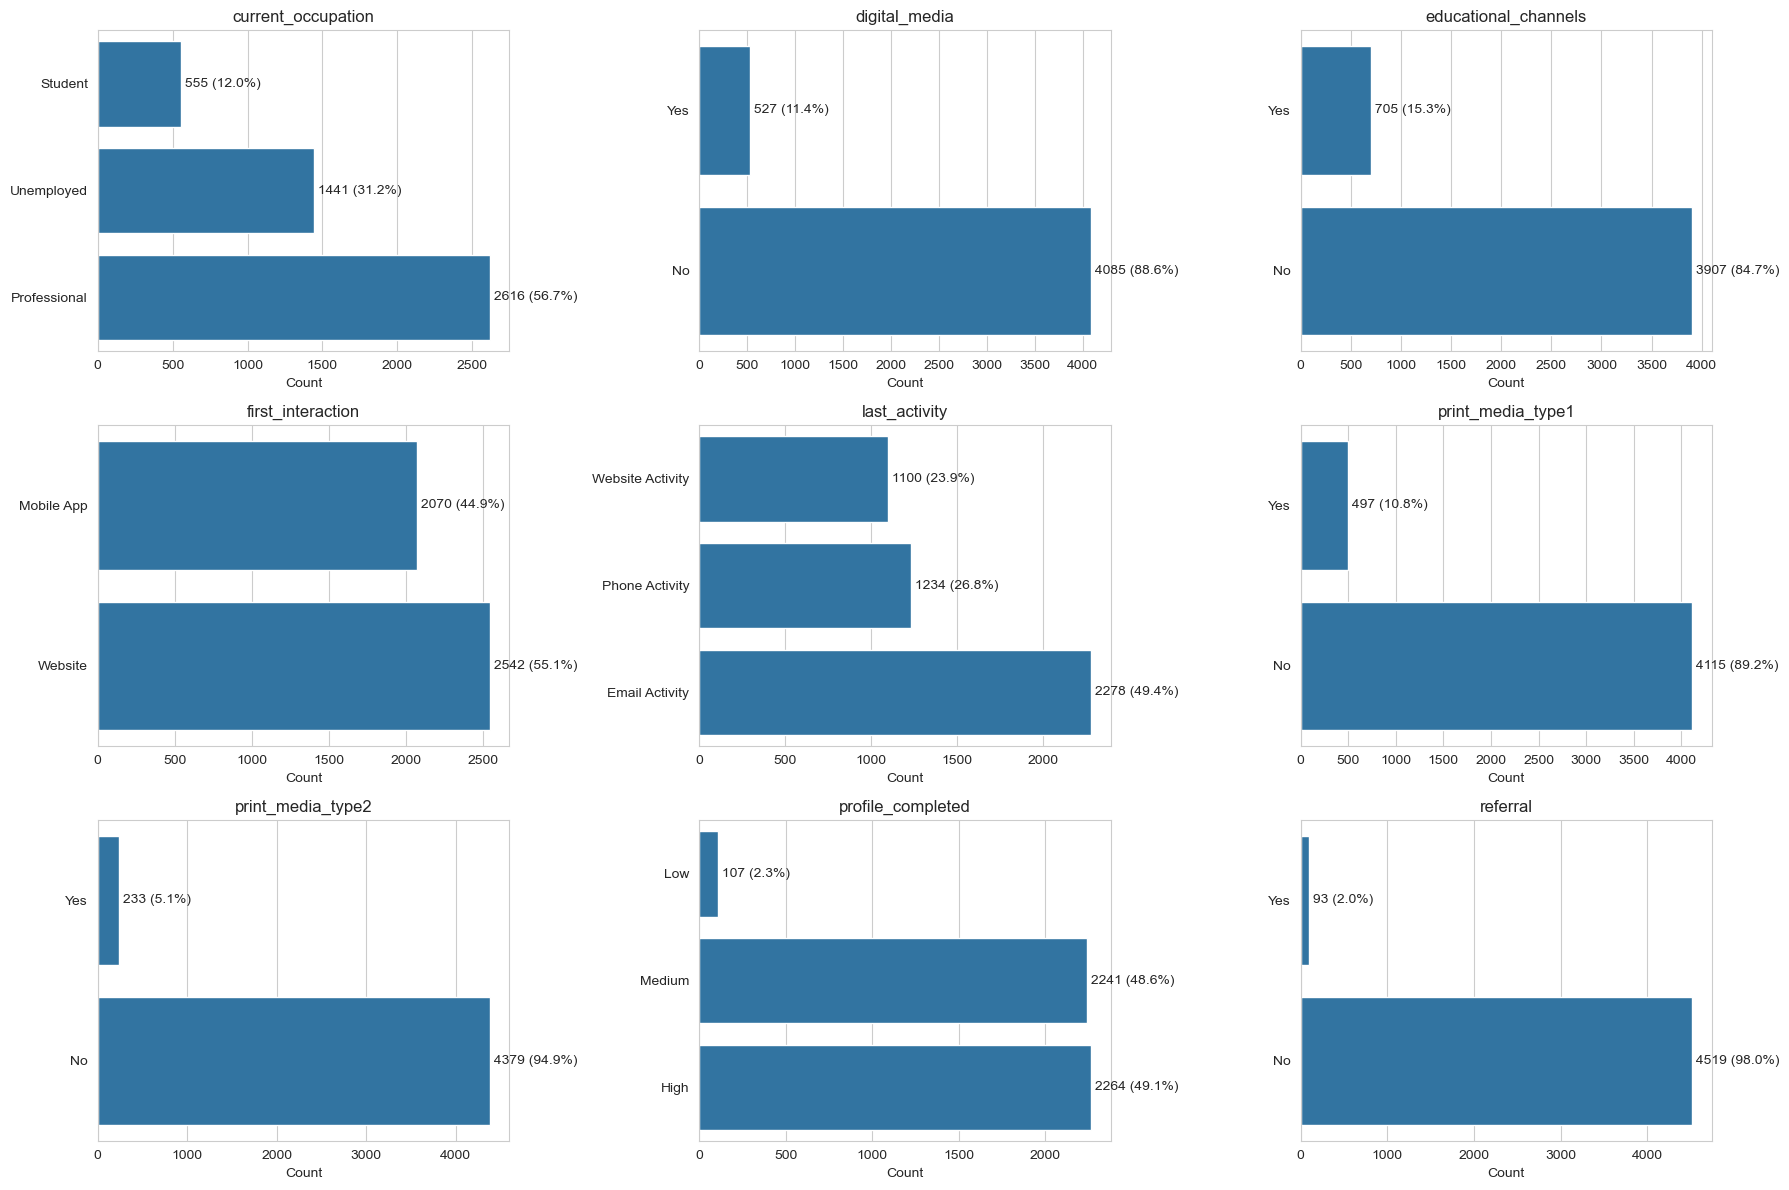

In [20]:
data_long = pdata[pdata.select_dtypes("object").columns].melt(var_name="variable", value_name="value")
sns.set_style("whitegrid")

# ---- compute counts ----
counts = (
    data_long
    .groupby(["variable", "value"])
    .size()
    .reset_index(name="count")
)

counts["percent"] = (
    counts.groupby("variable")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

variables = counts["variable"].unique()

# ---- layout parameters ----
cols = 3                          # variables per row
rows = int(np.ceil(len(variables) / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(cols * 6, rows * 4)
)

axes = axes.flatten()

# ---- plotting ----
for ax, var in zip(axes, variables):

    subset = counts[counts["variable"] == var].sort_values("count", ascending=True)

    sns.barplot(
        data=subset,
        y="value",
        x="count",
        ax=ax
    )

    ax.set_title(var, fontsize=12)
    ax.set_xlabel("Count")
    ax.set_ylabel("")

    # labels
    for i, row in enumerate(subset.itertuples()):
        ax.text(
            row.count,
            i,
            f" {row.count} ({row.percent:.1f}%)",
            va="center"
        )

# remove unused axes
for ax in axes[len(variables):]:
    ax.remove()

plt.tight_layout()
plt.show()

* Distribution of data across all categorical variables.

#### Overview of numerical variables

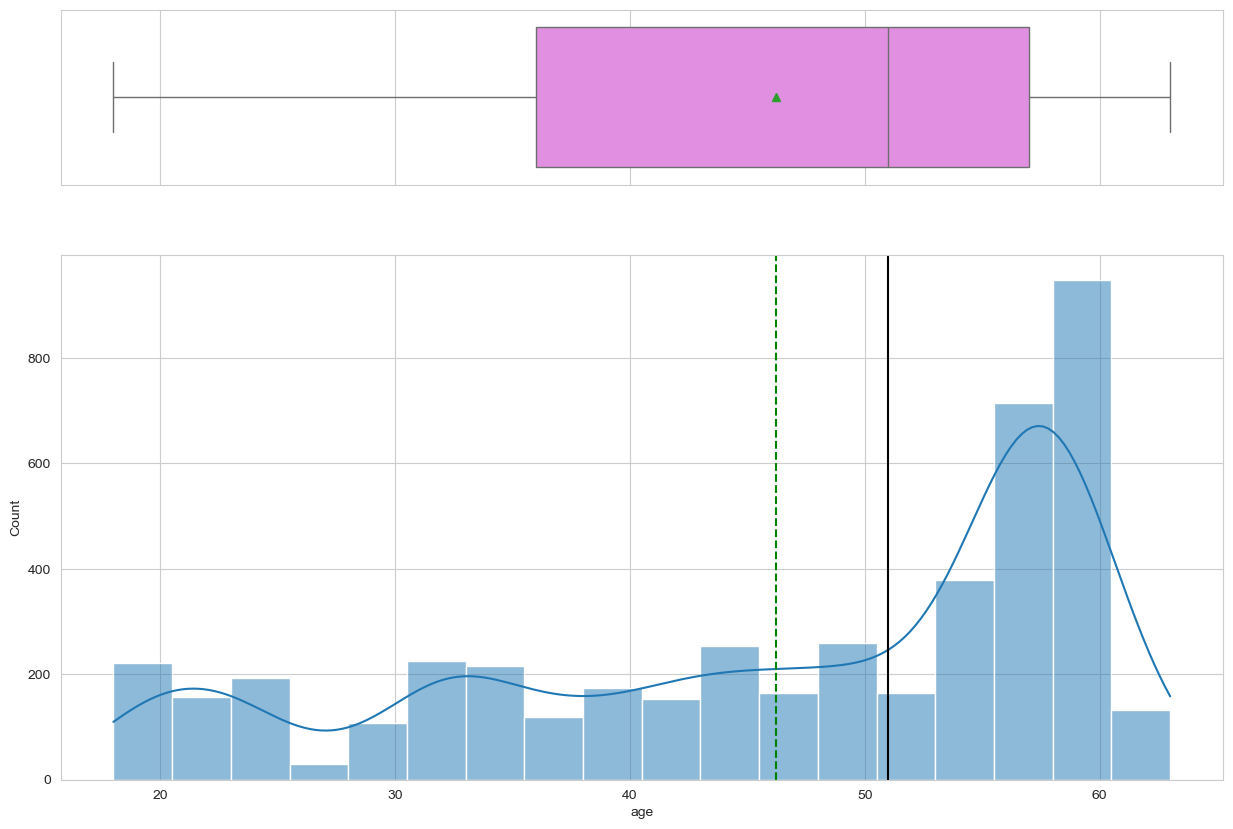

In [21]:
histogram_boxplot(data, "age", kde=True)

* Age is left skewed with the mean at aroun 46 and the median at around 51.

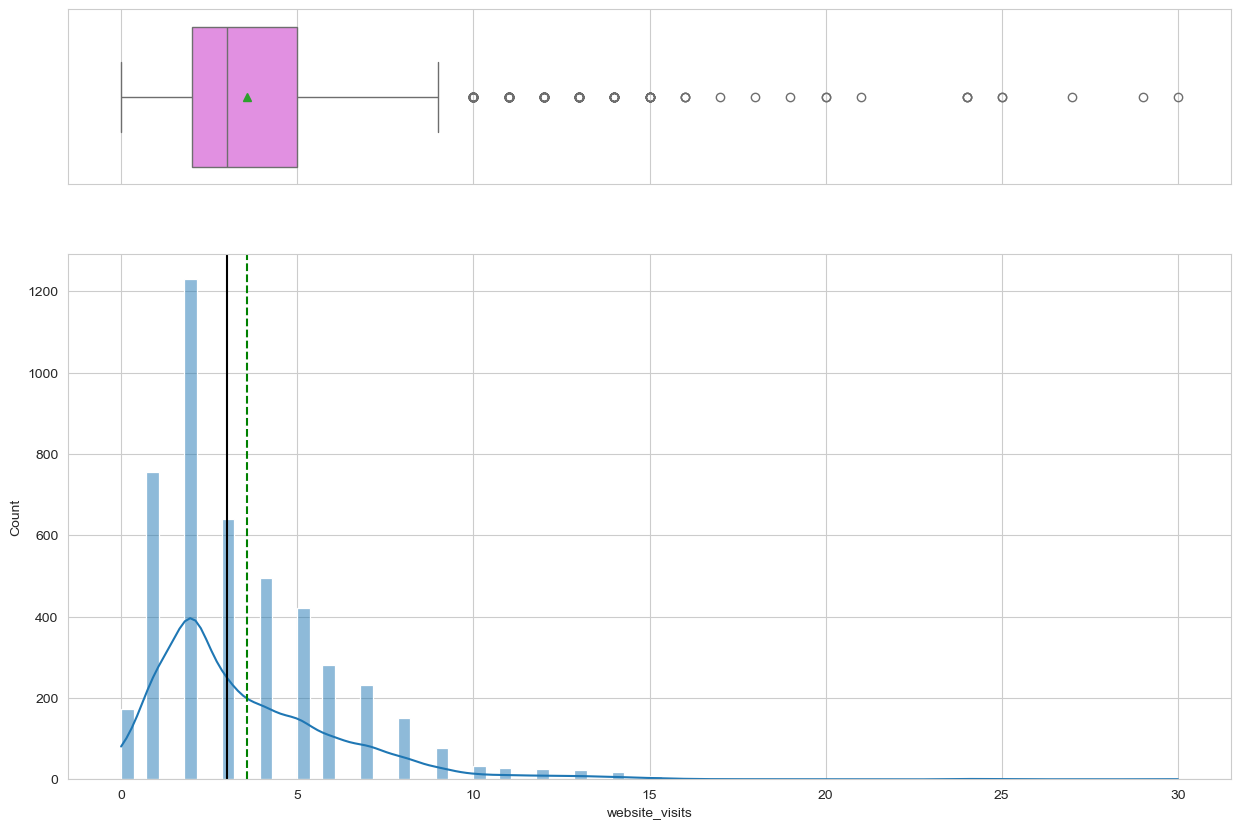

In [22]:
histogram_boxplot(pdata, "website_visits", kde=True)

* 75% of the observed leads have visited the website less than 5 times.

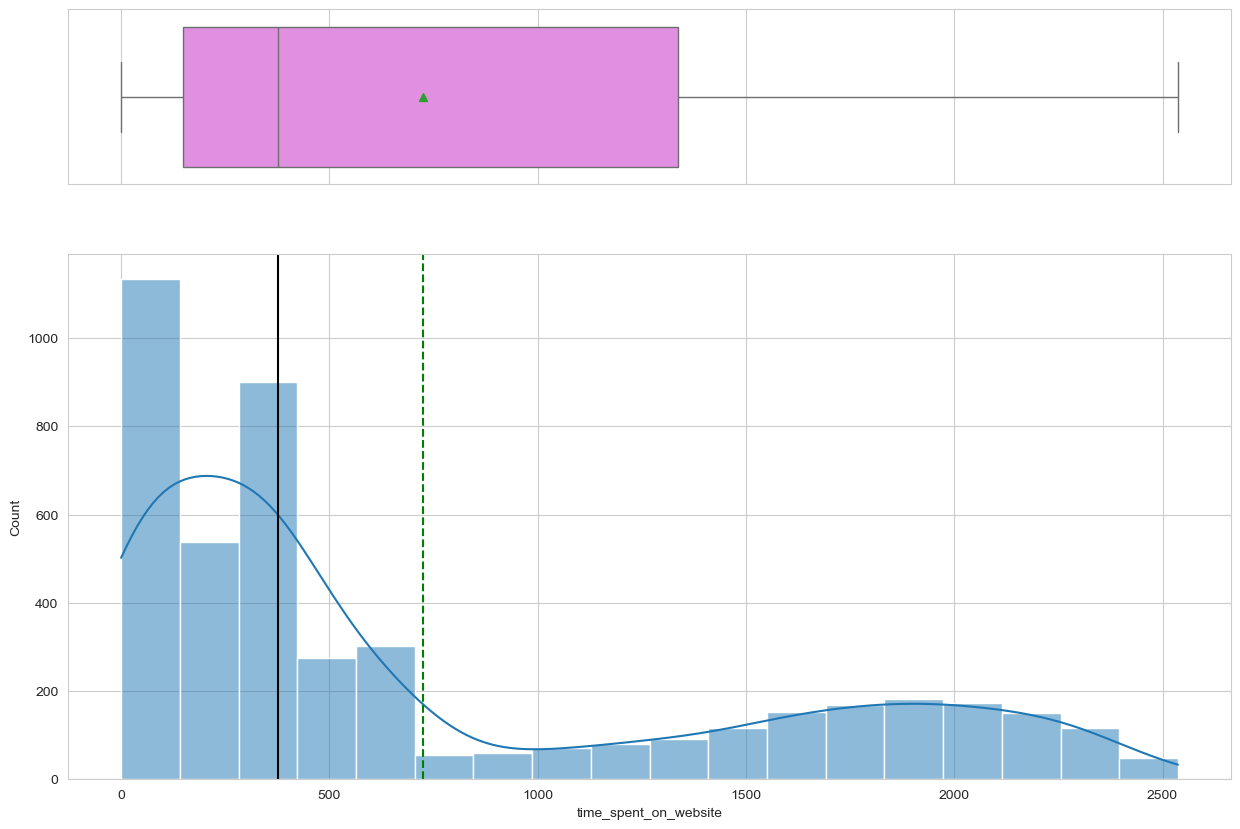

In [23]:
histogram_boxplot(pdata, "time_spent_on_website", kde=True)

* Time spent on website is right skewed, as most leads have spent less than 1500 s.

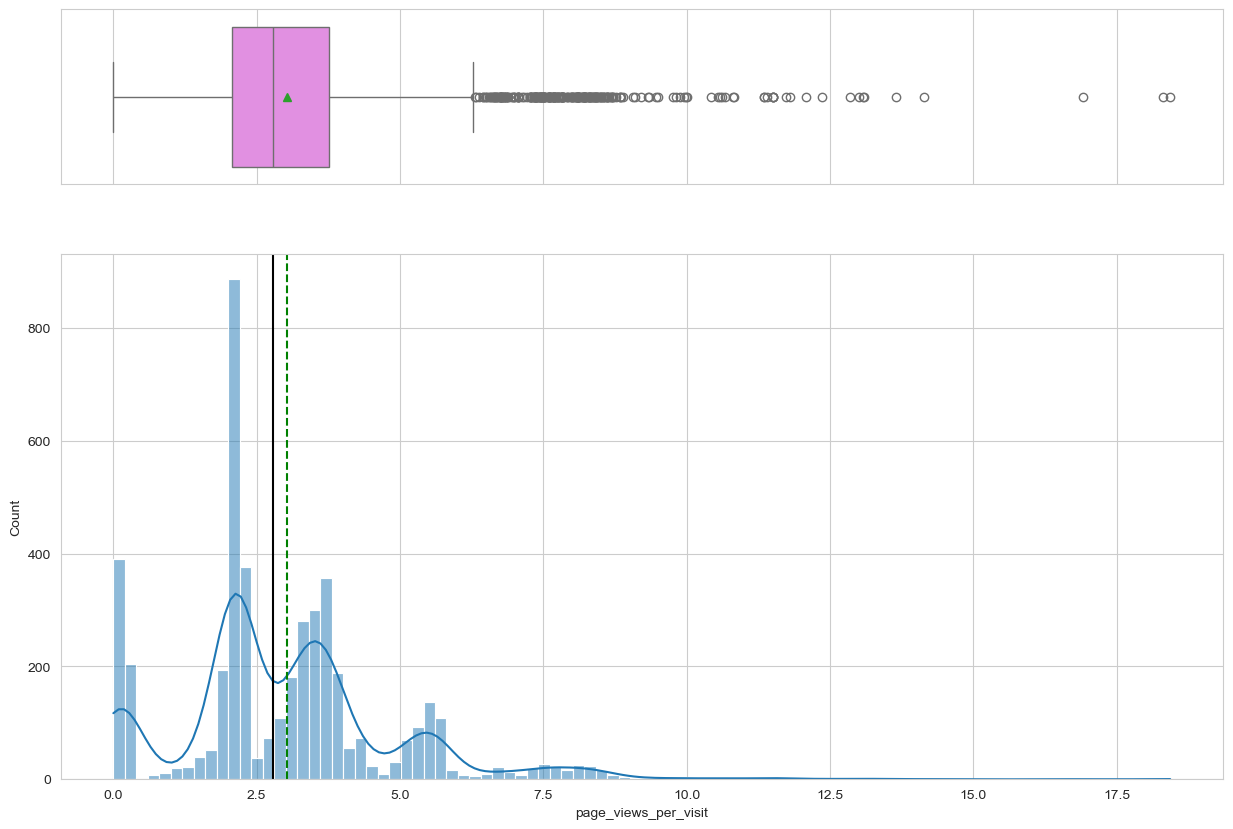

In [24]:
histogram_boxplot(pdata, "page_views_per_visit", kde=True)

* Finally page views per visit is right skewed. Although the high amount of leads who have visited none or almost no pages per visit drag the mean and median closer together.

### Bivariate Analysis

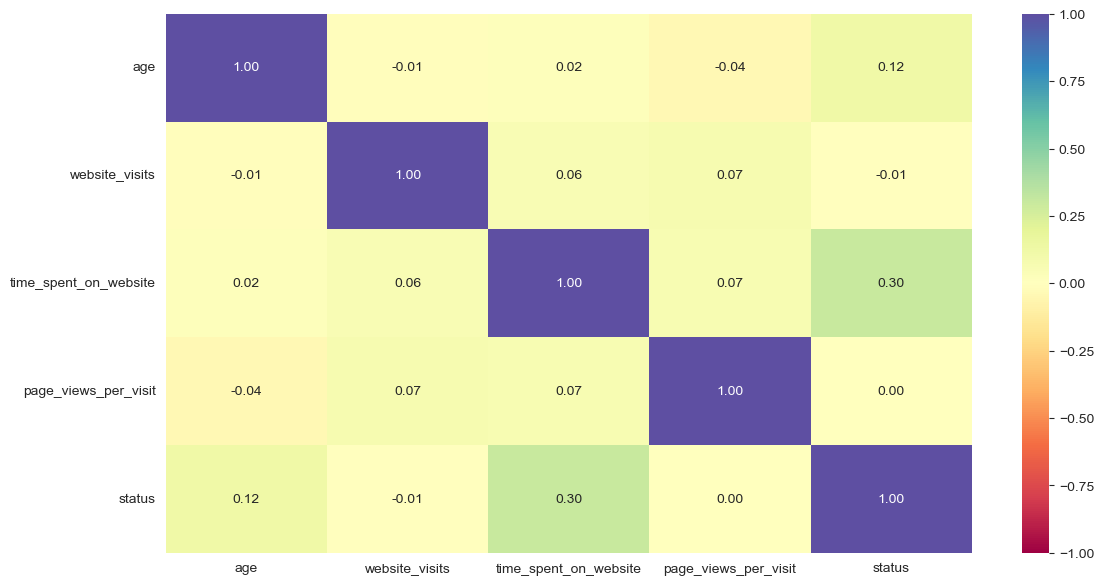

In [25]:
plt.figure(figsize=(13, 7))
sns.heatmap(pdata.select_dtypes(include=np.number).corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

* Time spent on website is the most significantly correlated variable to status (conversion). Age as well has some slight correlation while the correlation of the rest of variables seems pretty much negligible.

status                 0     1   All
current_occupation                  
All                 3235  1377  4612
Professional        1687   929  2616
Unemployed          1058   383  1441
Student              490    65   555
------------------------------------------------------------------------------------------------------------------------


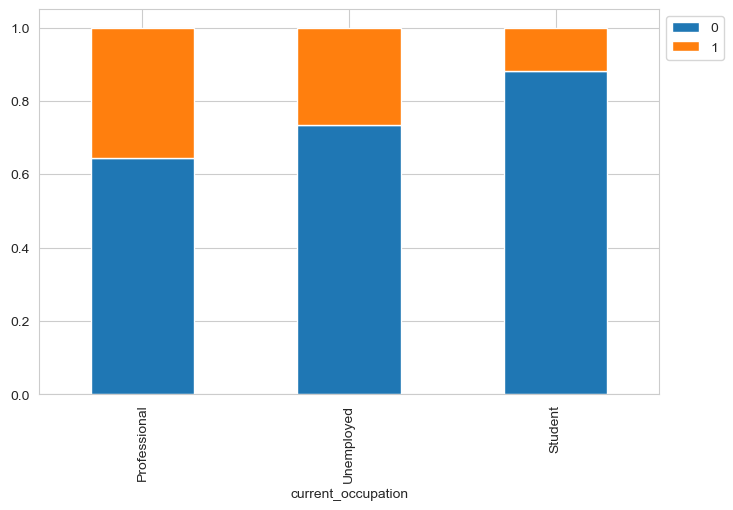

In [26]:
stacked_barplot(pdata, "current_occupation", "status")

* Most leads who convert to paid customers are professionals.

status                0     1   All
first_interaction                  
All                3235  1377  4612
Website            1383  1159  2542
Mobile App         1852   218  2070
------------------------------------------------------------------------------------------------------------------------


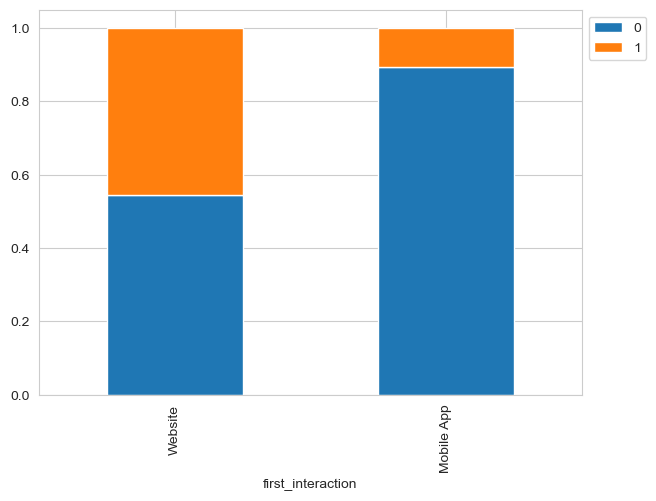

In [27]:
stacked_barplot(pdata, "first_interaction", "status")

* Most leads who convert to paid customers interact with the platform through the website first. 

status                0     1   All
profile_completed                  
All                3235  1377  4612
High               1318   946  2264
Medium             1818   423  2241
Low                  99     8   107
------------------------------------------------------------------------------------------------------------------------


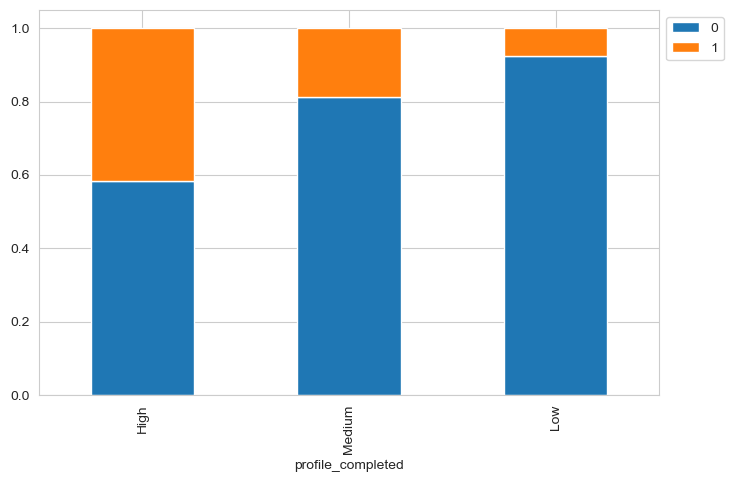

In [28]:
stacked_barplot(pdata, "profile_completed", "status")

* Leads with a high level of profile completion convert to paid customers more often and in greater numbers.

status               0     1   All
last_activity                     
All               3235  1377  4612
Email Activity    1587   691  2278
Website Activity   677   423  1100
Phone Activity     971   263  1234
------------------------------------------------------------------------------------------------------------------------


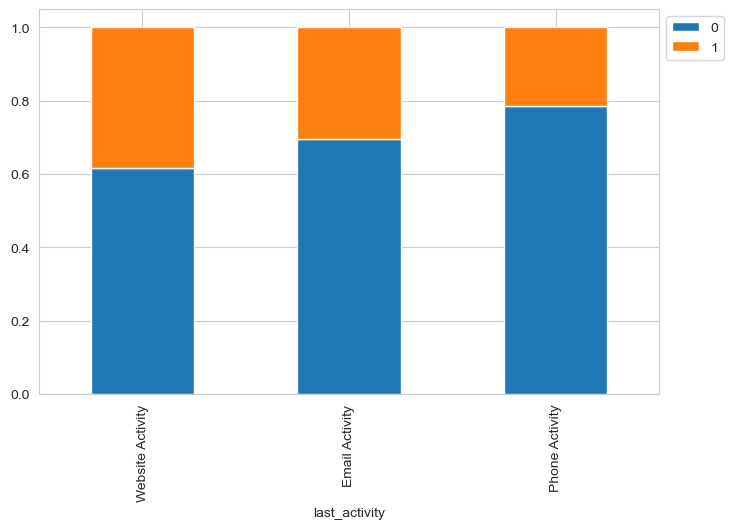

In [29]:
stacked_barplot(pdata, "last_activity", "status")

* Leads who have last interacted with the website present a higher proportion of conversion to paid customers.

# **Data Preprocessing**

## Outlier Check

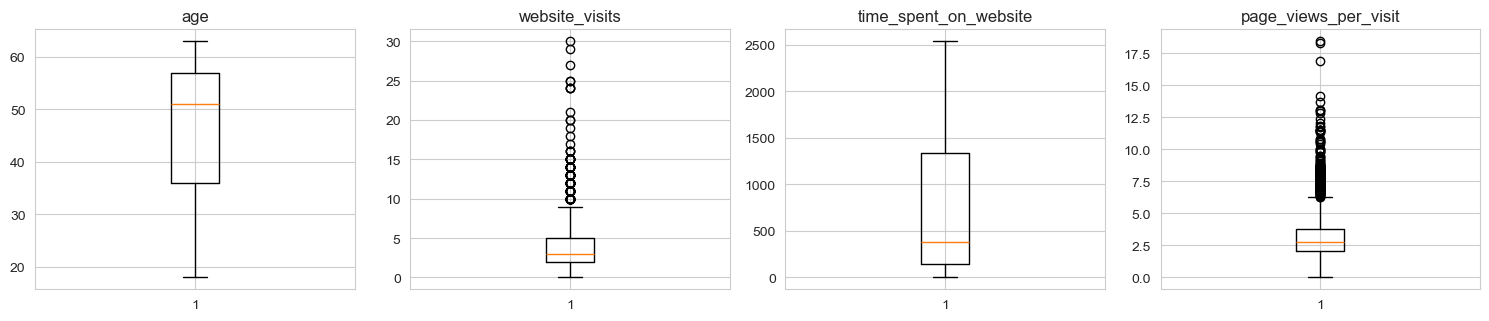

In [30]:
# outlier detection using boxplot
numeric_columns = pdata.select_dtypes(include=np.number).columns.tolist()
# dropping release_year as it is a temporal variable
numeric_columns.remove("status")

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

* As decision trees are less sensitive to outliers than linear models we can leave them as they are.

## Data Preparation for modeling

- We want to predict which lead is more likely to be converted.
- Before we proceed to build a model, we'll have to encode categorical features.
- We'll split the data into train and test to be able to evaluate the model that we build on the train data.

In [31]:
X = pdata.drop(["status"], axis=1)     #Complete the code by dropping the independent variable
Y = pdata["status"]     #Complete the code by selecting the dependent variable

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1
)

In [32]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3228, 13)
Shape of test set :  (1384, 13)
Percentage of classes in training set:
status
0    0.704151
1    0.295849
Name: proportion, dtype: float64
Percentage of classes in test set:
status
0    0.695087
1    0.304913
Name: proportion, dtype: float64


## **Data Pre-processing Pipeline**

In [33]:
categorical_features = pdata.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features

['current_occupation',
 'first_interaction',
 'profile_completed',
 'last_activity',
 'print_media_type1',
 'print_media_type2',
 'digital_media',
 'educational_channels',
 'referral']

In [34]:
# Create a preprocessing pipeline for the categorical features

preprocessor = make_column_transformer(
    (Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
)

# **Model Building**

## Model Evaluation Criterion

* Recall and F1 score are particularly important for this problem, since we are looking to ccapture as many converters as possible.

## Define functions for Model Evaluation

In [35]:
from src.evaluate import model_performance_classification

## Decision Tree Model

In [36]:
from src.model import train_decision_tree

dtree = train_decision_tree(preprocessor, X_train, y_train)
dtree

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

### Checking model performance on training set

In [37]:
dtree_model_train_perf = model_performance_classification(dtree, X_train, y_train)
dtree_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.830235,0.634555,0.752795,0.688636


### Checking model performance on test set

In [38]:
dtree_model_test_perf = model_performance_classification(dtree, X_test, y_test)
dtree_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.784682,0.580569,0.669399,0.621827


# **Model Performance Improvement - Hyperparameter Tuning**

## Hyperparameter Tuning - Decision Tree

In [39]:
# Choose the type of classifier.
dtree_tuned = DecisionTreeClassifier(random_state=1)
dtree_tuned = make_pipeline(preprocessor,dtree_tuned)

# Grid of parameters to choose from
parameters = {
    "decisiontreeclassifier__max_depth": [None, 5, 10, 15, 20],     #Complete the code
    "decisiontreeclassifier__max_leaf_nodes": [20, 30, 40, 50, 60],     #Complete the code
    "decisiontreeclassifier__min_samples_leaf": [1, 2, 3, 5]     #Complete the code
}

# Run the grid search
grid_obj = GridSearchCV(dtree_tuned, parameters, scoring="recall", cv=5, n_jobs =-1)
grid_obj = grid_obj.fit(X_train, y_train)
print(grid_obj.best_params_)

# Set the clf to the best combination of parameters
dtree_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
dtree_tuned.fit(X_train, y_train)

{'decisiontreeclassifier__max_depth': None, 'decisiontreeclassifier__max_leaf_nodes': 60, 'decisiontreeclassifier__min_samples_leaf': 1}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

### Checking model performance on training set

In [40]:
dtree_tuned_model_train_perf = model_performance_classification(
    dtree_tuned, X_train, y_train
)
dtree_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.825589,0.636649,0.737864,0.68353


### Checking model performance on test set

In [41]:
dtree_tuned_model_test_perf = model_performance_classification(dtree_tuned, X_test, y_test)
dtree_tuned_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.787572,0.582938,0.675824,0.625954


* The model is performing with an expected difference between train and test data.

# **Model Performance Comparison, Final Model Selection, and Serialization**

In [42]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        dtree_model_train_perf.T,
        dtree_tuned_model_train_perf.T
    ],
    axis=1,
)

models_train_comp_df.columns = [
    "Decision Tree",
    "Decision Tree Tuned"
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree,Decision Tree Tuned
Accuracy,0.830235,0.825589
Recall,0.634555,0.636649
Precision,0.752795,0.737864
F1,0.688636,0.683530


In [43]:
# Testing performance comparison

models_test_comp_df = pd.concat(
    [
        dtree_model_test_perf.T,
        dtree_tuned_model_test_perf.T
    ],
    axis=1,
)

models_test_comp_df.columns = [
    "Decision Tree",
    "Decision Tree Tuned"
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Decision Tree,Decision Tree Tuned
Accuracy,0.784682,0.787572
Recall,0.580569,0.582938
Precision,0.669399,0.675824
F1,0.621827,0.625954


* Hyperparameter tuning achieved a slight improvement on the test data. Which means that the original model was slightly overfitting the data.

In [44]:
dtree_tuned.named_steps

{'columntransformer': ColumnTransformer(transformers=[('pipeline',
                                  Pipeline(steps=[('encoder',
                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                  ['current_occupation', 'first_interaction',
                                   'profile_completed', 'last_activity',
                                   'print_media_type1', 'print_media_type2',
                                   'digital_media', 'educational_channels',
                                   'referral'])]),
 'decisiontreeclassifier': DecisionTreeClassifier(max_leaf_nodes=60, random_state=1)}

In [45]:
["# Save the tuned model for deployment","joblib.dump(dtree_tuned, 'dtree_tuned_model.joblib')","print('Model saved as dtree_tuned_model.joblib')"]

['# Save the tuned model for deployment',
 "joblib.dump(dtree_tuned, 'dtree_tuned_model.joblib')",
 "print('Model saved as dtree_tuned_model.joblib')"]

In [47]:
cat_features = [
'current_occupation',
'first_interaction',
'profile_completed',
'last_activity',
'print_media_type1',
'print_media_type2',
'digital_media',
'educational_channels',
'referral'
]

ohe = dtree_tuned.named_steps["columntransformer"] \
        .named_transformers_["pipeline"] \
        .named_steps["encoder"]

feature_names = ohe.get_feature_names_out(cat_features)

importances = dtree_tuned.named_steps["decisiontreeclassifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
3,first_interaction_Mobile App,0.364609
5,profile_completed_High,0.303776
1,current_occupation_Student,0.095498
9,last_activity_Phone Activity,0.049030
2,current_occupation_Unemployed,0.039924
0,current_occupation_Professional,0.031369
8,last_activity_Email Activity,0.024914
18,educational_channels_Yes,0.015260
19,referral_No,0.011650
10,last_activity_Website Activity,0.010249


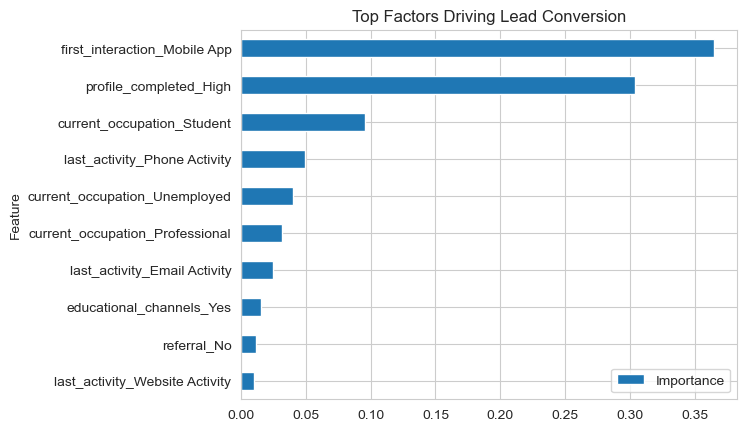

In [48]:
feature_importance_df.head(10).plot(
    kind="barh",
    x="Feature",
    y="Importance"
)

plt.gca().invert_yaxis()
plt.title("Top Factors Driving Lead Conversion")
plt.show()

* Out of the categorical variables we can see that first interaction via mobile app and profile completion level high are the top factors driving lead conversion. As well we had observed earlier the considerable correlation between time spent on website and conversion.

In [49]:
dtree_tuned.named_steps["columntransformer"].get_feature_names_out()

array(['pipeline__current_occupation_Professional',
       'pipeline__current_occupation_Student',
       'pipeline__current_occupation_Unemployed',
       'pipeline__first_interaction_Mobile App',
       'pipeline__first_interaction_Website',
       'pipeline__profile_completed_High',
       'pipeline__profile_completed_Low',
       'pipeline__profile_completed_Medium',
       'pipeline__last_activity_Email Activity',
       'pipeline__last_activity_Phone Activity',
       'pipeline__last_activity_Website Activity',
       'pipeline__print_media_type1_No',
       'pipeline__print_media_type1_Yes',
       'pipeline__print_media_type2_No',
       'pipeline__print_media_type2_Yes', 'pipeline__digital_media_No',
       'pipeline__digital_media_Yes', 'pipeline__educational_channels_No',
       'pipeline__educational_channels_Yes', 'pipeline__referral_No',
       'pipeline__referral_Yes'], dtype=object)

#### Let's serialize the tuned model

In [50]:
os.makedirs("backend_files", exist_ok=True)

In [51]:
saved_model_path = "backend_files/learn_model.joblib"

In [52]:
joblib.dump(dtree_tuned, saved_model_path)

print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at backend_files/learn_model.joblib


In [53]:
saved_model = joblib.load("backend_files/learn_model.joblib")

print("Model loaded successfully.")

Model loaded successfully.


In [54]:
saved_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [55]:
saved_model.predict(X_test)

array([0, 0, 0, ..., 1, 0, 1], shape=(1384,))

# **Deployment**

## Dockerfile

In [56]:
%%writefile backend_files/requirements.txt
streamlit
pandas
numpy
scikit-learn==1.6.1
matplotlib
seaborn
joblib==1.4.2

Overwriting backend_files/requirements.txt


In [57]:
%%writefile backend_files/Dockerfile
FROM python:3.10-slim

# Create non-root user (required by Hugging Face)
RUN useradd -m -u 1000 user
USER user
ENV PATH="/home/user/.local/bin:$PATH"

WORKDIR /app

COPY --chown=user requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY --chown=user . .

CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0"]

Overwriting backend_files/Dockerfile


In [58]:

["%%writefile backend_files/app.py","import streamlit as st","import pandas as pd","import joblib","","# Load model","model = joblib.load('../dtree_tuned_model.joblib')","","st.title('ExtraaLearn Lead Conversion Prediction')","st.write('Fill in the details below to predict whether the lead will convert (status).')","","# Collect user input","age = st.number_input('Age', min_value=0, step=1)","current_occupation = st.selectbox('Current Occupation', ['Professional', 'Unemployed', 'Student'])","first_interaction = st.selectbox('First Interaction', ['Website', 'Mobile App'])","profile_completed = st.selectbox('Profile Completed', ['High', 'Medium', 'Low'])","website_visits = st.number_input('Website Visits', min_value=0, step=1)","time_spent_on_website = st.number_input('Time Spent on Website (seconds)', min_value=0, step=1)","page_views_per_visit = st.number_input('Page Views per Visit', min_value=0.0, step=0.001, format='%.3f')","last_activity = st.selectbox('Last Activity', ['Email Activity', 'Phone Activity', 'Website Activity'])","print_media_type1 = st.selectbox('Print Media Type 1', ['No', 'Yes'])","print_media_type2 = st.selectbox('Print Media Type 2', ['No', 'Yes'])","digital_media = st.selectbox('Digital Media', ['No', 'Yes'])","educational_channels = st.selectbox('Educational Channels', ['No', 'Yes'])","referral = st.selectbox('Referral', ['No', 'Yes'])","","# Convert input into DataFrame","input_data = pd.DataFrame({","    'age': [age],","    'current_occupation': [current_occupation],","    'first_interaction': [first_interaction],","    'profile_completed': [profile_completed],","    'website_visits': [website_visits],","    'time_spent_on_website': [time_spent_on_website],","    'page_views_per_visit': [page_views_per_visit],","    'last_activity': [last_activity],","    'print_media_type1': [print_media_type1],","    'print_media_type2': [print_media_type2],","    'digital_media': [digital_media],","    'educational_channels': [educational_channels],","    'referral': [referral]","})","","# Predict","if st.button('Predict Status'):","    prediction = model.predict(input_data)[0]","    probability = model.predict_proba(input_data)[0][1]","","    st.subheader('Prediction Result:')","    st.write('Converted' if prediction == 1 else 'Not Converted')","    st.write(f'Confidence: {probability:.2f}')"]

['%%writefile backend_files/app.py',
 'import streamlit as st',
 'import pandas as pd',
 'import joblib',
 '',
 '# Load model',
 "model = joblib.load('../dtree_tuned_model.joblib')",
 '',
 "st.title('ExtraaLearn Lead Conversion Prediction')",
 "st.write('Fill in the details below to predict whether the lead will convert (status).')",
 '',
 '# Collect user input',
 "age = st.number_input('Age', min_value=0, step=1)",
 "current_occupation = st.selectbox('Current Occupation', ['Professional', 'Unemployed', 'Student'])",
 "first_interaction = st.selectbox('First Interaction', ['Website', 'Mobile App'])",
 "profile_completed = st.selectbox('Profile Completed', ['High', 'Medium', 'Low'])",
 "website_visits = st.number_input('Website Visits', min_value=0, step=1)",
 "time_spent_on_website = st.number_input('Time Spent on Website (seconds)', min_value=0, step=1)",
 "page_views_per_visit = st.number_input('Page Views per Visit', min_value=0.0, step=0.001, format='%.3f')",
 "last_activity = st.s

## requirements.txt

In [59]:
["%%writefile backend_files/requirements.txt","streamlit==1.28.1","numpy==2.0.2","pandas==2.2.2","scikit-learn==1.6.1","joblib==1.4.2","matplotlib==3.10.0","seaborn==0.13.2"]

['%%writefile backend_files/requirements.txt',
 'streamlit==1.28.1',
 'numpy==2.0.2',
 'pandas==2.2.2',
 'scikit-learn==1.6.1',
 'joblib==1.4.2',
 'matplotlib==3.10.0',
 'seaborn==0.13.2']

## app.py

In [60]:
%%writefile backend_files/app.py


UsageError: %%writefile is a cell magic, but the cell body is empty.


["## HuggingFace Space Deployment","To deploy this app on HuggingFace Spaces:","1. Go to [HuggingFace Spaces](https://huggingface.co/spaces)","2. Create a new Space with Streamlit","3. Upload the `app.py` and `requirements.txt` files from `backend_files/`","4. Upload the trained model `dtree_tuned_model.joblib` (save it first using `joblib.dump(dtree_tuned, 'dtree_tuned_model.joblib')`)","5. The app will be live at your Space URL, e.g., https://huggingface.co/spaces/berns722/lead_conversion_prediction_model"]

In [ ]:
["# Upload the model to HuggingFace Hub (optional, for sharing the model)","from huggingface_hub import HfApi","api = HfApi()","api.upload_file(","    path_or_fileobj='dtree_tuned_model.joblib',","    path_in_repo='dtree_tuned_model.joblib',","    repo_id='berns722/lead_conversion_prediction_model',","    repo_type='model'"," )","print('Model uploaded to HuggingFace Hub.')"]

['# Upload the model to HuggingFace Hub (optional, for sharing the model)',
 'from huggingface_hub import HfApi',
 'api = HfApi()',
 'api.upload_file(',
 "    path_or_fileobj='dtree_tuned_model.joblib',",
 "    path_in_repo='dtree_tuned_model.joblib',",
 "    repo_id='berns722/lead_conversion_prediction_model',",
 "    repo_type='model'",
 ' )',
 "print('Model uploaded to HuggingFace Hub.')"]

# **Actionable Insights and Business Recommendations**

* We have reviewed through analysis that variables such as profile completion and first interaction mobile app are crucial for lead conversion. As well other variables which do not seem as important could be exploited through tactics such as making them more appealing.
* The lead conversion prediction model can be implemented into a decision making workflow, as it can also be further trained on new data to improve its performance.

# <font size=6 color='blue'>Power Ahead</font>
___